# Data cleaning: Condition Monitoring of Hydraulic Systems

This notebook performs data cleaning for the "Condition Monitoring of Hydraulic Systems" dataset, building on the findings from the previous exploratory data analysis (EDA). The main objective is to transform the feature matrix constructed from sensor signals into a clean, consistent dataset ready for modeling (the silver layer of the medallion architecture).

In this notebook, we will:

- Create and reply the process about X matrix on EDA to after cleaning it.
- Identify and treat outliers according to the recommendations from the exploratory analysis (Basically keep those data (literature recomendation)).
- Handle missing values through imputation or removal, ensuring no bias or information leakage is introduced.
- Standardize numerical variables to ensure comparability and robustness in subsequent models.
- Export the cleaned feature (X) and target (Y) matrices for use in later stages (feature engineering and modeling).

This process ensures that the silver database is robust, reproducible, and aligned with best practices from scientific literature and industrial data engineering.

# Libraries

In [24]:
# Import fundamental libraries for cleaning data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from numpy.polynomial.polynomial import Polynomial
import os
from sklearn.preprocessing import StandardScaler
import joblib

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Upload Data

In [3]:
data_dir = r"C:\Users\User\Documents\UdeA\Fundamentos Inteligencia Computacional\Proyecto\database\bronce"

files = [
    "CE.txt", "CP.txt", "EPS1.txt", "FS1.txt", "FS2.txt", "profile.txt",
    "PS1.txt", "PS2.txt", "PS3.txt", "PS4.txt", "PS5.txt", "PS6.txt",
    "SE.txt", "TS1.txt", "TS2.txt", "TS3.txt", "TS4.txt", "VS1.txt"
]

dataset = {} # dictionary to hold DataFrames for each file
for file in files:
    path = os.path.join(data_dir, file)
    df = pd.read_csv(path, sep="\t", header=None)
    dataset[file.replace(".txt", "")] = df

dataset["PS1"].head() # Display first few rows of PS1 dataset

,0,1,2,3,4,5,6,7,8,9,...,5990,5991,5992,5993,5994,5995,5996,5997,5998,5999
0,151.47,151.45,151.52,151.27,150.80,150.69,153.89,154.67,152.88,153.82,...,151.16,151.19,151.25,151.16,151.10,151.16,151.14,151.10,151.21,151.19
1,151.11,151.12,151.16,150.92,150.70,150.62,152.40,153.21,152.81,153.53,...,150.82,150.82,150.86,150.80,150.73,150.79,150.84,150.79,150.80,150.86
2,150.81,150.79,150.84,150.65,150.35,150.23,152.03,152.81,152.44,153.27,...,150.49,150.44,150.47,150.46,150.38,150.47,150.50,150.43,150.54,150.62
3,150.48,150.47,150.52,150.31,150.04,149.98,151.63,152.48,152.24,152.94,...,150.34,150.30,150.28,150.38,150.41,150.33,150.31,150.31,150.25,150.28
4,150.41,150.35,150.24,150.12,149.87,149.71,151.64,152.37,151.78,152.68,...,150.31,150.20,150.17,150.28,150.31,150.25,150.27,150.22,150.13,150.19


# Calculate Statistics to transform dataset

In [4]:
# Helper function to calculate slope
def calc_slope(x):
    """
    Calculate the slope of a linear fit to the data.

    Parameters:
    x (array-like): The input data for which to calculate the slope.
    Returns:
    float: The slope of the linear fit to the data or 0.0 if the fit cannot be computed.
    """
    idx = np.arange(len(x))
    if len(x) < 2:
        return 0.0
    p = Polynomial.fit(idx, x, 1)
    coef = p.convert().coef
    if len(coef) < 2:
        return 0.0
    return coef[1]

In [5]:
# List of statistics to compute
stats_functions = {
    'mean': np.mean,
    'std': np.std,
    'skew': skew,
    'kurtosis': kurtosis,
    'slope': calc_slope,
    'max': np.max
}

# Build the feature matrix (excluding 'profile')
features = []
for sensor, df in dataset.items():
    if sensor == "profile" or df.shape[1] < 2:
        continue
    for stat_name, func in stats_functions.items():
        col_name = f"{sensor}_{stat_name}"
        stat_values = df.apply(func, axis=1)
        features.append(stat_values.rename(col_name))

X = pd.concat(features, axis=1)

# Add profile columns with correct names
profile_columns = [
    "cooler_condition",
    "valve_condition",
    "internal_pump_leakage",
    "hydraulic_accumulator",
    "stable_flag"
]
profile_df = dataset["profile"].copy()
profile_df.columns = profile_columns

# Concatenate features and profile info
X = pd.concat([X, profile_df], axis=1)

print(f"Feature matrix shape: {X.shape}")
X.head()

Feature matrix shape: (2205, 107)


,CE_mean,CE_std,CE_skew,CE_kurtosis,CE_slope,CE_max,CP_mean,CP_std,CP_skew,CP_kurtosis,...,VS1_std,VS1_skew,VS1_kurtosis,VS1_slope,VS1_max,cooler_condition,valve_condition,internal_pump_leakage,hydraulic_accumulator,stable_flag
0,39.601350,6.317224,-0.267015,-1.419685,-0.359653,47.438,1.862750,0.277047,-0.345513,-1.406497,...,0.026852,-0.044978,-1.275101,-0.000618,0.624,3,100,0,130,1
1,25.786433,1.672019,0.401015,-1.097494,-0.094054,29.208,1.255550,0.073981,0.402252,-1.149507,...,0.027013,0.770789,-0.238839,-0.000858,0.626,3,100,0,130,1
2,22.218233,0.633003,0.304239,-1.103712,-0.032079,23.554,1.113217,0.023069,0.245656,-0.877893,...,0.036422,0.934103,-0.042351,-0.001313,0.662,3,100,0,130,1
3,20.459817,0.451941,0.183835,-0.251527,-0.013245,21.565,1.062150,0.024415,-0.027257,-1.036550,...,0.033184,1.007775,-0.165555,-0.000875,0.645,3,100,0,130,1
4,19.787017,0.287728,-0.025580,-0.073937,-0.002295,20.460,1.070467,0.021297,-0.482068,-0.357209,...,0.033203,0.795914,0.027945,-0.001028,0.660,3,100,0,130,1


# Analysis of Outliers

In [9]:
Y = X[profile_columns]
X_features = X.drop(columns=profile_columns)

print(f"Features shape: {X_features.shape}")
print(f"Targets shape: {Y.shape}")

# Identify and count outliers using the IQR method, and relate to stable_flag
outlier_summary = []
for col in X_features.columns:
    Q1 = X_features[col].quantile(0.25)
    Q3 = X_features[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (X_features[col] < lower_bound) | (X_features[col] > upper_bound)
    # Count outliers by stable_flag
    stable_0 = ((outliers) & (Y["stable_flag"] == 0)).sum()
    stable_1 = ((outliers) & (Y["stable_flag"] == 1)).sum()
    total_outliers = outliers.sum()
    outlier_summary.append({
        "variable": col,
        "total_outliers": int(total_outliers),
        "stable_flag_0": int(stable_0),
        "stable_flag_1": int(stable_1)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df[outlier_df["total_outliers"] > 0]
outlier_df_sorted = outlier_df.sort_values("variable")
with pd.option_context('display.max_rows', None):
    display(outlier_df_sorted)

Features shape: (2205, 102)
Targets shape: (2205, 5)


,variable,total_outliers,stable_flag_0,stable_flag_1
3,CE_kurtosis,77,58,19
2,CE_skew,30,26,4
4,CE_slope,81,58,23
1,CE_std,52,34,18
9,CP_kurtosis,86,65,21
8,CP_skew,13,11,2
10,CP_slope,90,58,32
7,CP_std,77,50,27
15,EPS1_kurtosis,240,233,7
12,EPS1_mean,10,10,0


In [13]:
# Calculate the mean value of outliers for each variable
outlier_values_summary = []
for col in X_features.columns:
    Q1 = X_features[col].quantile(0.25)
    Q3 = X_features[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (X_features[col] < lower_bound) | (X_features[col] > upper_bound)
    outlier_vals = X_features.loc[outliers, col]
    if len(outlier_vals) > 0:
        mean_outlier = outlier_vals.mean()
        min_outlier = outlier_vals.min()
        max_outlier = outlier_vals.max()
        outlier_values_summary.append({
            "variable": col,
            "num_outliers": len(outlier_vals),
            "mean_outlier": mean_outlier,
            "min_outlier": min_outlier,
            "max_outlier": max_outlier
        })

# Mostrar resumen de valores outlier por variable
outlier_values_df = pd.DataFrame(outlier_values_summary)
outlier_values_df = outlier_values_df[outlier_values_df["num_outliers"] > 0]
outlier_values_df = outlier_values_df.sort_values("variable")
with pd.option_context('display.max_rows', None):
    display(outlier_values_df.sort_values("variable"))

,variable,num_outliers,mean_outlier,min_outlier,max_outlier
2,CE_kurtosis,77,2.048880e+00,0.938631,9.441696
1,CE_skew,30,3.443731e-01,-1.663728,2.896980
3,CE_slope,81,-2.874371e-03,-0.359653,0.314772
0,CE_std,52,8.418188e-01,0.494271,6.317224
6,CP_kurtosis,86,1.481845e+00,0.862886,9.068864
5,CP_skew,13,2.657095e-01,-1.376809,2.763207
7,CP_slope,90,-1.398889e-04,-0.015649,0.019299
4,CP_std,77,5.067291e-02,0.006856,0.340648
11,EPS1_kurtosis,240,-1.440392e+00,-1.922300,1.097346
8,EPS1_mean,10,2.725716e+03,2708.453467,2740.641000


## conclusions

Based on the exploratory data analysis and recommendations from the scientific literature, the following approach will be taken regarding outliers in the feature matrix:

- Outliers will be retained in the dataset. The literature on industrial condition monitoring (e.g., ZeMA dataset studies) suggests that outliers in sensor data often correspond to real, rare, or extreme operating conditions, early signs of failure, or sensor noise that is relevant for predictive maintenance.

- No rows or values will be removed or imputed solely due to being statistical outliers. Removing these data points could result in the loss of critical information about system degradation or rare failure modes.

- All features will be preserved as-is for downstream modeling. Robust machine learning models (such as tree-based methods) are generally capable of handling outliers without significant performance degradation.

- Outlier detection results will be documented for transparency. The summary statistics and visualizations generated during EDA will be kept as reference for future analysis and model interpretation.

> In summary: Outliers are considered potentially informative for fault detection and diagnosis in hydraulic systems. Therefore, the dataset will be kept intact, ensuring that all operational scenarios are represented in the silver layer.

# Missing Values

In [14]:
numeric_cols = X_features.select_dtypes(include=[float, int]).columns
# 1. Quantify missing values for each variable
missing_counts = X_features.isnull().sum()
print("Missing values per variable:")
print(missing_counts[missing_counts > 0])

Missing values per variable:
PS4_skew        1238
PS4_kurtosis    1238
dtype: int64


In [11]:
X["PS4_kurtosis"]

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
2200   -0.566282
2201   -0.557666
2202   -0.483664
2203   -0.383418
2204   -0.396480
Name: PS4_kurtosis, Length: 2205, dtype: float64

In [12]:
X["PS4_skew"]

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
2200   -0.111436
2201   -0.129698
2202   -0.145645
2203   -0.210954
2204   -0.219537
Name: PS4_skew, Length: 2205, dtype: float64

In [15]:
# imputation of missing values using gaussian sampling (mean and std of the column)
for col in ["PS4_skew", "PS4_kurtosis"]:
    mean = X_features[col].mean()
    std = X_features[col].std()
    n_missing = X_features[col].isnull().sum()
    # generate random values from a normal distributtion with the same media and std of the column
    random_values = np.random.normal(loc=mean, scale=std, size=n_missing)
    X_features.loc[X_features[col].isnull(), col] = random_values

# Verify
print(X_features[["PS4_skew", "PS4_kurtosis"]].isnull().sum())

PS4_skew        0
PS4_kurtosis    0
dtype: int64


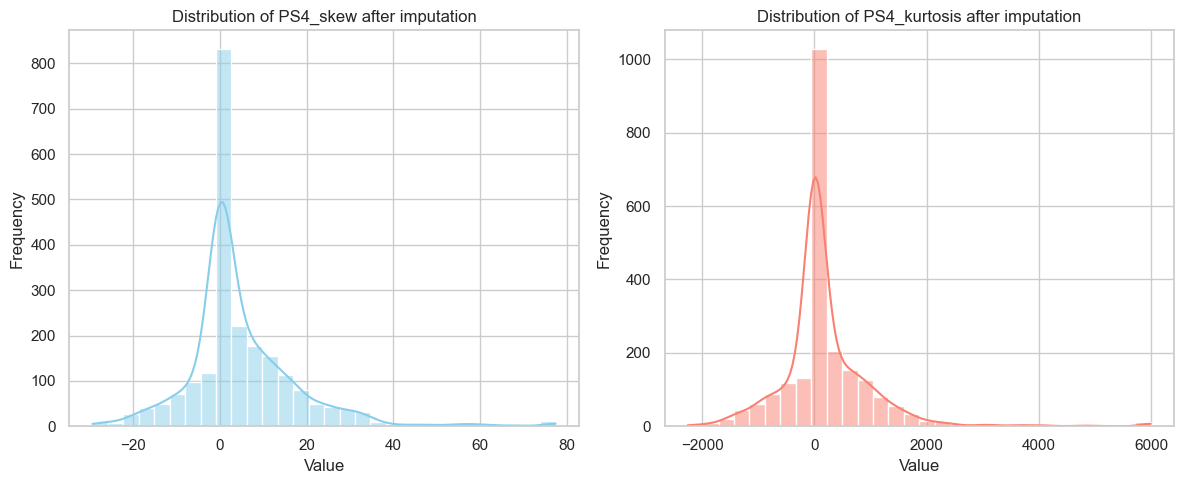

In [20]:
# plot the distribution of PS4_skew and PS4_kurtosis after imputation
X["PS4_skew"] = X_features["PS4_skew"]
X["PS4_kurtosis"] = X_features["PS4_kurtosis"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(X["PS4_skew"], bins=30, ax=axes[0], kde=True, color="skyblue")
sns.histplot(X["PS4_kurtosis"], bins=30, ax=axes[1], kde=True, color="salmon")
titles = ["Distribution of PS4_skew after imputation", "Distribution of PS4_kurtosis after imputation"]
for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


# Standarize

In [22]:
# Select only numeric columns from X_features
numeric_cols = X_features.select_dtypes(include=[float, int]).columns

# initialize the scaler
scaler = StandardScaler()

# Adjust and transform the data
X_features_scaled = pd.DataFrame(
    scaler.fit_transform(X_features[numeric_cols]),
    columns=numeric_cols,
    index=X_features.index
)

# Update X with the standardized values
for col in numeric_cols:
    X[col] = X_features_scaled[col]

# Verify that the mean is approximately 0 and std is approximately 1 for the numeric columns
print("Mean of standardized numeric columns:")
print(X[numeric_cols].mean().round(4))
print("Standard deviation of standardized numeric columns:")
print(X[numeric_cols].std().round(4))

Mean of standardized numeric columns:
CE_mean         0.0
CE_std         -0.0
CE_skew        -0.0
CE_kurtosis     0.0
CE_slope        0.0
               ... 
VS1_std         0.0
VS1_skew        0.0
VS1_kurtosis    0.0
VS1_slope      -0.0
VS1_max        -0.0
Length: 102, dtype: float64
Standard deviation of standardized numeric columns:
CE_mean         1.0002
CE_std          1.0002
CE_skew         1.0002
CE_kurtosis     1.0002
CE_slope        1.0002
                 ...  
VS1_std         1.0002
VS1_skew        1.0002
VS1_kurtosis    1.0002
VS1_slope       1.0002
VS1_max         1.0002
Length: 102, dtype: float64


# Export to Silver

In [25]:
silver_dir = os.path.join("..", "database", "silver")
os.makedirs(silver_dir, exist_ok=True)

X_features_scaled.to_csv(os.path.join(silver_dir, "X_silver.csv"), index=False)
Y.to_csv(os.path.join(silver_dir, "Y.csv"), index=False)
joblib.dump(scaler, os.path.join(silver_dir, "standard_scaler_X.pkl"))

print(f"Complete Export to: {os.path.abspath(silver_dir)}")

Complete Export to: c:\Users\User\Documents\UdeA\Fundamentos Inteligencia Computacional\Proyecto\database\silver


# General Conclusions and Next Steps

## Summary of Data Cleaning Notebook (Silver Layer)

1. **Feature Matrix Construction**
- Built the feature matrix (X) from raw sensor signals using statistical descriptors: mean, standard deviation, skewness, kurtosis, slope, and max.
- Added system condition variables from the profile file to form the target matrix (Y).
Outlier Analysis and Policy

2. **Detected outliers in all variables using the IQR method.**
- Following scientific literature and domain knowledge, decided to retain outliers as they may represent rare operating conditions or early signs of failure.

3. **Missing Value Imputation**
- Identified missing values in PS4_skew and PS4_kurtosis.
- Imputed missing values by generating random numbers from a Gaussian distribution fitted to each   column, preserving variance and statistical structure.

4. **Standardization**
- Standardized all numeric variables using StandardScaler to ensure zero mean and unit variance, improving comparability and model robustness.

5. **Export of Cleaned Data**
- Exported the cleaned and standardized feature matrix (X_silver.csv), the target matrix (Y.csv), and the trained scaler object (standard_scaler_X.pkl) to the silver folder for future use and reproducibility.


---

## Next Steps: Feature Extraction Notebook (Gold Layer)

In the feature extraction notebook, we will further enrich the dataset to create the "gold" layer, optimized for advanced analytics and machine learning. Planned steps include:

1. **Advanced Feature Engineering:**  
   - Create new features based on domain knowledge, signal processing (e.g., frequency-domain features), or interaction terms.
2. **Dimensionality Reduction (Optional):**  
   - Apply techniques such as PCA or autoencoders if further reduction is needed for specific models or deployment constraints.
3. **Feature Selection for Modeling:**  
   - Use the results from supervised selection (RFE, SelectFromModel) to retain only the most informative features for each target.
4. **Final Matrix Assembly:**  
   - Construct the final X_gold matrix, ready for model training and evaluation.
5. **Documentation and Export:**  
   - Document all transformations and export the gold dataset for reproducibility.

---

> **This structured workflow ensures that each stage of the data pipeline is transparent, reproducible, and aligned with best practices in industrial predictive maintenance.**